# Analyze Base Edits from LN DMS Screen

RBakker March 11, 2025

### Load Libraries

In [94]:
options(warn = -1)

suppressPackageStartupMessages({
  library(plyranges)
  library(tidyverse)
  library(rasilabRtemplates)
  library(ggpubr)
  library(RColorBrewer)
  library(ggseqlogo)
})

### Read in Annotations

In [95]:
insert_annotations <- read_csv("../annotations/insert_annotations.csv", show_col_types = F) %>%
    print()

barcode_annotations <- read_csv("../data/filtered_barcodes/filtered_barcodes_linkage.csv", show_col_types = F) %>%
    print()

# A tibble: 1,387 × 8
   wt_codon codon_position mut_codon insert_seq     wt_aa mut_aa inser…¹ row_num
   <chr>             <dbl> <chr>     <chr>          <chr> <chr>  <chr>     <dbl>
 1 ATG                   1 TTT       TTTGACGCTCAGA… M     F      GTTGGC…       1
 2 ATG                   1 TTC       TTCGACGCTCAGA… M     F      GTTGGC…       2
 3 ATG                   1 TTA       TTAGACGCTCAGA… M     L      GTTGGC…       3
 4 ATG                   1 TTG       TTGGACGCTCAGA… M     M      GTTGGC…       4
 5 ATG                   1 TCT       TCTGACGCTCAGA… M     S      GTTGGC…       5
 6 ATG                   1 TCC       TCCGACGCTCAGA… M     S      GTTGGC…       6
 7 ATG                   1 TCA       TCAGACGCTCAGA… M     S      GTTGGC…       7
 8 ATG                   1 TCG       TCGGACGCTCAGA… M     S      GTTGGC…       8
 9 ATG                   1 TAT       TATGACGCTCAGA… M     Y      GTTGGC…       9
10 ATG                   1 TAC       TACGACGCTCAGA… M     Y      GTTGGC…      10
# … wi

### Read In Data

In [96]:
target_data <- list.files("../data/summary_stats/", full.names = T, pattern = ".csv") %>%
    read_csv(show_col_types = F) %>%
    janitor::clean_names() %>%
    left_join(barcode_annotations, by = "barcode") %>%
    left_join(insert_annotations, by = c("insert_num"="row_num")) %>%
    print()

# A tibble: 7,925 × 97
   barcode       read_…¹ num_0_a num_0_g num_0_t num_0_c num_0_n num_1_a num_1_g
   <chr>           <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 CCGAAGCCGCAA…    1772    1771    1771       1    1427    1772       0       0
 2 AGCGACAACAGA…     746     746     745       0     429     746       0       1
 3 AAGGCGCCCGGC…     785     784     784       1     678     785       0       0
 4 CAAGAAGAAACC…    2337    2334    2335       0    2144    2337       3       1
 5 GAGCACGAAGGG…     974     974     974       0     584     974       0       0
 6 CGGCAACAGGCC…    1632    1629    1630       0    1070    1632       3       1
 7 GGGCGGGAAGGC…    1449    1447    1448       0    1315    1449       2       1
 8 ACAACCACGAGG…     389     389     389       0     388     389       0       0
 9 CCAGAGAAAACC…     718     716     716       0     249     718       2       2
10 AGCGCCAAACGG…    2079    2079    2077       0    1527    2079       0       2
# … w

### How many reads per barcode?

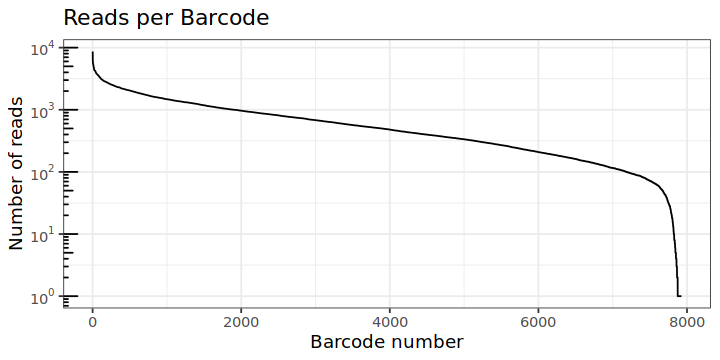

In [97]:
plot_data <- target_data %>%
  arrange(desc(read_counts)) %>%
  mutate(xaxis = 1:dplyr::n()) %>%
  ungroup()

plot_data %>% 
  ggplot(aes(x = xaxis, y = read_counts)) +
  geom_line() +
  theme_bw() +
  scale_y_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +
  annotation_logticks(sides = 'l')  +
  labs(x = "Barcode number", y = "Number of reads",
      title = "Reads per Barcode") +
  scale_color_manual(values = c(cbPalette, "blue")) +
  theme(text = element_text(family='Sans')) +
  NULL


### How Many Barcodes Per Insert?

# A tibble: 1,299 × 4
   insert_num barcodes reads xaxis
        <dbl>    <int> <dbl> <int>
 1         36      110 48616     1
 2        446       46 41146     2
 3        502       46 33750     3
 4        445       40 21354     4
 5        498       40 30620     5
 6        443       39 21264     6
 7        504       38 24999     7
 8        477       37 33803     8
 9        492       37 24570     9
10        505       37 28267    10
# … with 1,289 more rows


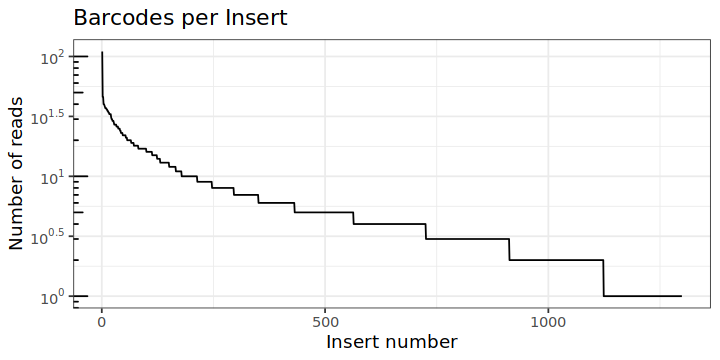

In [98]:
plot_data <- target_data %>%
group_by(insert_num)%>%
  summarize(barcodes=n(),reads=sum(read_counts))%>%
  ungroup()%>%
  arrange(-barcodes)%>%
  mutate(xaxis = 1:dplyr::n()) %>%
  ungroup()%>%
  print()

plot_data %>% 
  ggplot(aes(x = xaxis, y = barcodes)) +
  geom_line() +
  theme_bw() +
  scale_y_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +
  annotation_logticks(sides = 'l')  +
  labs(x = "Insert number", y = "Number of reads",
      title = "Barcodes per Insert") +
  scale_color_manual(values = c(cbPalette, "blue")) +
  theme(text = element_text(family='Sans')) +
  NULL


### Reads Per Insert

# A tibble: 1,299 × 4
   insert_num barcodes reads xaxis
        <dbl>    <int> <dbl> <int>
 1         36      110 48616     1
 2        446       46 41146     2
 3        477       37 33803     3
 4        502       46 33750     4
 5        453       29 31007     5
 6        498       40 30620     6
 7        505       37 28267     7
 8        493       36 27609     8
 9        454       34 27046     9
10        319       26 27004    10
# … with 1,289 more rows


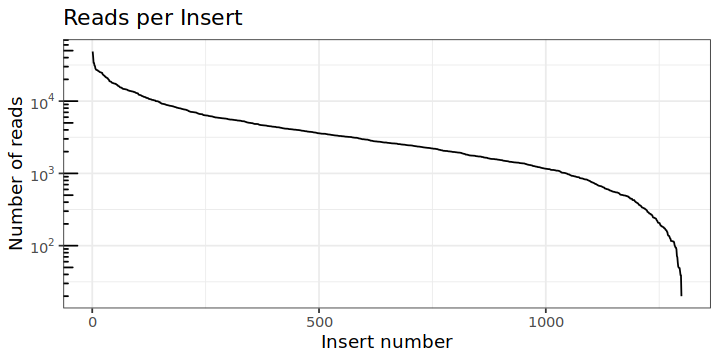

In [99]:
plot_data <- target_data %>%
group_by(insert_num)%>%
  summarize(barcodes=n(),reads=sum(read_counts))%>%
  ungroup()%>%
  arrange(-reads)%>%
  mutate(xaxis = 1:dplyr::n()) %>%
  ungroup()%>%
  print()

plot_data %>% 
  ggplot(aes(x = xaxis, y = reads)) +
  geom_line() +
  theme_bw() +
  scale_y_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +
  annotation_logticks(sides = 'l')  +
  labs(x = "Insert number", y = "Number of reads",
      title = "Reads per Insert") +
  scale_color_manual(values = c(cbPalette, "blue")) +
  theme(text = element_text(family='Sans')) +
  NULL


### Calculate Mean Editing for Wildtype LN

- Wildtype LN is insert #36
- This value should be similar to other experiments

# A tibble: 8 × 4
      n position     mean        se
  <int> <chr>       <dbl>     <dbl>
1   103 0        0.0166   0.0103   
2   103 1        0.0949   0.0215   
3   103 2        0.000163 0.0000879
4   103 3        0.0188   0.0110   
5   103 4        0.0612   0.0182   
6   103 5        0.0179   0.0116   
7   103 6        0.00439  0.00314  
8   103 7        0.129    0.0242   


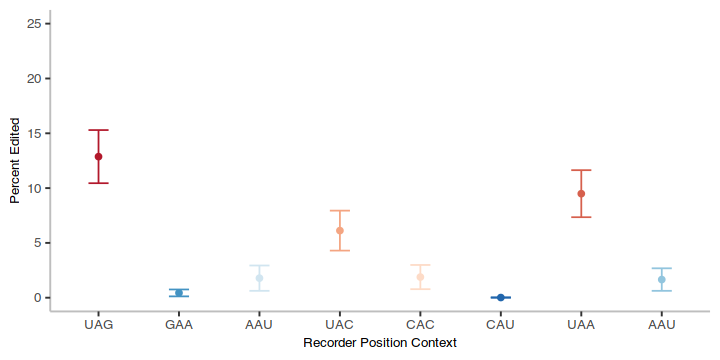

In [100]:
options(repr.plot.width = 6, repr.plot.height = 3)
position_labs=c("7"="UAG",
"6"="GAA",
"5"="AAU",
"4"= "UAC",
"3"= "CAC",
"2"= "CAU",
"1"= "UAA",
"0"= "AAU"
)
position_order=c("7","6","5","4","3","2","1","0")

plot_data <- target_data  %>%
  filter(insert_num==36,read_counts>20) %>%
  mutate(across(matches("pos_._c"), ~ round(.x / read_counts, 5), .names = "fraction_{col}")) %>%
  select(matches("fraction_")) %>%
  summarize(across(matches("fraction_"),~mean(.x),.names="mean_{col}"),
    across(starts_with("fraction_"),~sd(.x)/sqrt(n()),.names="se_{col}"),
    n=n(),
    .groups = "drop")%>%
      pivot_longer(
      cols = c(starts_with("mean_"),starts_with("se_")), 
      names_to = c(".value", "position"),
      names_pattern = "(mean|se)_fraction_pos_(\\d+)_c"
    )%>%
  print()

plot_data  %>%
  ggplot(aes(x = factor(position,level=position_order), y = mean*100,color=as_factor(mean))) +  
  geom_point() +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_x_discrete(labels=position_labs)+
  scale_y_continuous(limits = c(0, 25)) +
  scale_color_brewer(palette = "RdBu",direction= -1)+
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "Recorder Position Context", y = "Percent Edited")



# Overall Editing

- Straight WT vs All Synonymous
- Synonymous Mutations matter?

# A tibble: 2 × 4
  type                  mean     se     n
  <chr>                <dbl>  <dbl> <int>
1 Synonymous Mutations 0.190 0.0128   405
2 Wildtype             0.218 0.0306   103


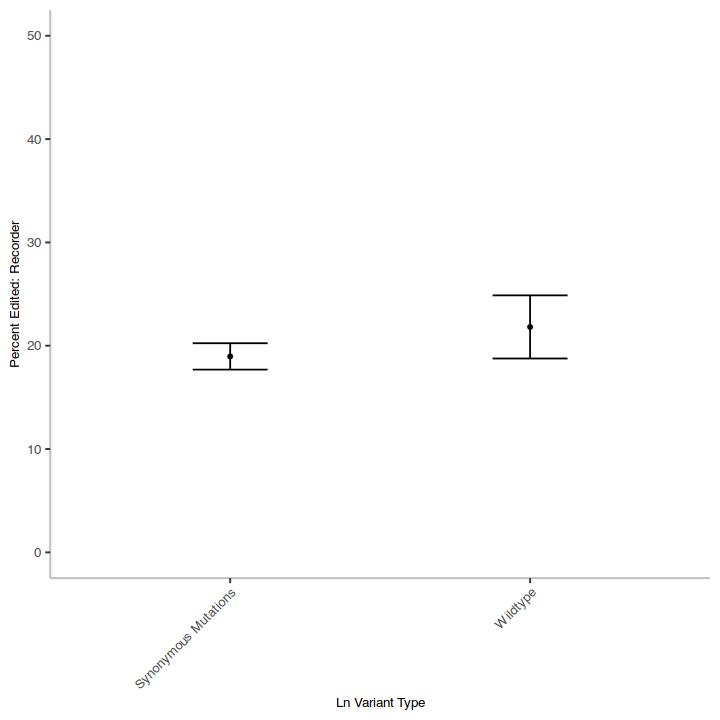

In [101]:
options(repr.plot.width = 6, repr.plot.height = 6)

plot_data <- target_data  %>%
  filter(wt_aa==mut_aa,read_counts>20) %>%
  mutate(type=case_when(
    insert_num==36 ~ "Wildtype",
    insert_num != 36 ~ "Synonymous Mutations"
  ))%>%
  group_by(type)%>%
  mutate(across(matches("num_._c"), ~ round(.x / read_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_c) %>%
  select(type,matches("fraction_")) %>%
  group_by(type) %>%
  summarize(mean=mean(fraction_edited),
  se=sd(fraction_edited)/sqrt(n()),
  n=n(),
  .groups = "drop")%>%
  print()

plot_data  %>%
  ggplot(aes(x = type, y = mean*100)) +  
  geom_point(size=1) +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
#   scale_x_discrete(labels=c("None","N-TadA","GFPNb-TadA"))+
  scale_y_continuous(limits = c(0, 50)) +
      theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      axis.text.x=element_text(angle=45,hjust=1),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey")
    )+
    labs(x = "Ln Variant Type", y = "Percent Edited: Recorder")

### Position Averages

Mean Edited for Ln Position

# A tibble: 22 × 4
   codon_position   mean      se     n
            <dbl>  <dbl>   <dbl> <int>
 1              1 0.208  0.0204    191
 2              2 0.212  0.0220    151
 3              3 0.156  0.0132    343
 4              4 0.141  0.0212    117
 5              5 0.175  0.0174    195
 6              6 0.122  0.00773   776
 7              7 0.0964 0.00662   823
 8              8 0.107  0.00522  1438
 9              9 0.221  0.0147    341
10             10 0.105  0.00908   489
# … with 12 more rows


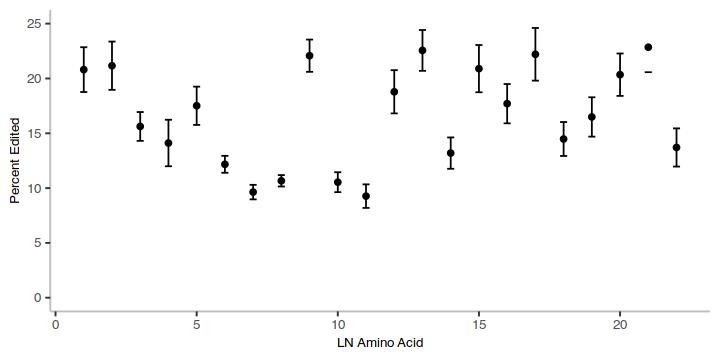

In [102]:
options(repr.plot.width = 6, repr.plot.height = 3)

plot_data <- target_data  %>%
  filter(wt_aa!=mut_aa,read_counts>20) %>%
  mutate(across(matches("num_._c"), ~ round(.x / read_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_c) %>%
  select(codon_position,matches("fraction_")) %>%
  group_by(codon_position) %>%
  summarize(mean=mean(fraction_edited),
  se=sd(fraction_edited)/sqrt(n()),
  n=n(),
  .groups = "drop")%>%
  print()

plot_data  %>%
  ggplot(aes(x = codon_position, y = mean*100)) +  
  geom_point() +
  geom_errorbar(aes(ymin = (mean - se)*100, ymax = (mean + se)*100), width = 0.25) +
  scale_y_continuous(limits = c(0, 25)) +
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "LN Amino Acid", y = "Percent Edited")

### Amino Acid Heatmaps


- No cutoffs or filtering, what does it look like?

# A tibble: 460 × 5
   codon_position mut_aa fraction_edited fraction_sd      lfc
            <dbl> <chr>            <dbl>       <dbl>    <dbl>
 1              9 R               0.225       0.0331  0.232  
 2              8 A               0.142       0.0193 -0.439  
 3              6 S               0.115       0.0211 -0.738  
 4              6 W               0.0893      0.0238 -1.10   
 5             10 K               0.193       0.0386  0.00534
 6             22 K               0.161       0.115  -0.256  
 7              1 T               0.150       0.0450 -0.358  
 8             18 *               0.190       0.0675 -0.0110 
 9             14 F               0.219       0.0513  0.189  
10              1 R               0.220       0.0301  0.197  
# … with 450 more rows


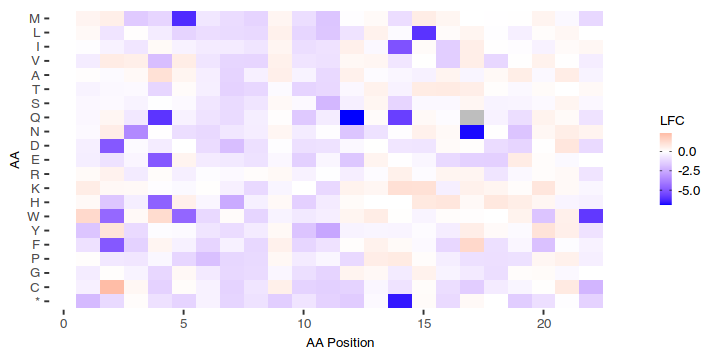

In [105]:

aa_reorder_list <- c("M", "L", "I", "V", "A", "T", "S", "Q", "N", "D", "E", "R", "K", "H", "W", "Y", "F", "P", "G", "C", "*")

calc_fraction_bootstrap <- function(data, indices) {
  d <- data[indices,]
  1-(sum(d$num_0_c)/sum(d$read_counts))
}
set.seed <- 1234

lfc_data <- target_data  %>%
  group_by(codon_position,mut_aa)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  mutate(lfc=log2(fraction_edited)-log2(wt_editing))%>%
  print()

lfc_data %>%
    ggplot(aes(x=codon_position,y=mut_aa,fill=lfc))+
        geom_tile()+
        scale_fill_gradient2(
            name = "LFC",
            low = "blue",       
            mid = "white",      
            high = "red",       
            midpoint = 0,       
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"),
            na.value = "grey"
    )+
        # scale_fill_gradient(
        #     name="Percent Edited",
        #     low = "white", high = "black",
        #     # limits = c(10, 30),
        #     guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        scale_y_discrete(limits = rev(aa_reorder_list))+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            )+
        labs(x = "AA Position", y = "AA",
         )

# A tibble: 460 × 5
   codon_position mut_aa fraction_edited fraction_sd     lfc
            <dbl> <chr>            <dbl>       <dbl>   <dbl>
 1              9 R               0.223       0.0297  0.217 
 2              8 A               0.137       0.0190 -0.491 
 3              6 S               0.120       0.0191 -0.673 
 4              6 W               0.0885      0.0212 -1.12  
 5             10 K               0.198       0.0439  0.0436
 6             22 K               0.152       0.118  -0.333 
 7              1 T               0.160       0.0470 -0.258 
 8             18 *               0.181       0.0633 -0.0858
 9             14 F               0.229       0.0544  0.257 
10              1 R               0.228       0.0328  0.245 
# … with 450 more rows


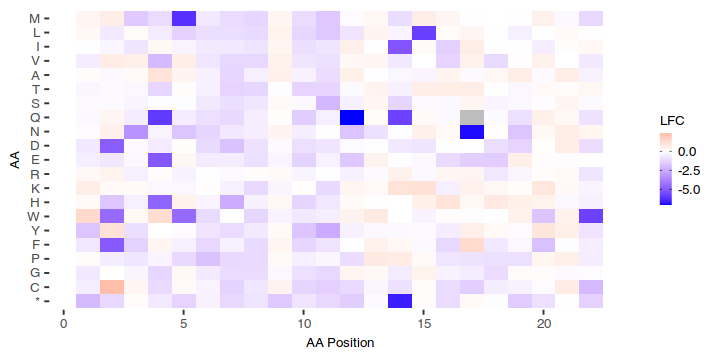

In [ ]:
aa_reorder_list <- c("M", "L", "I", "V", "A", "T", "S", "Q", "N", "D", "E", "R", "K", "H", "W", "Y", "F", "P", "G", "C", "*")

calc_fraction_bootstrap <- function(data, indices) {
  d <- data[indices,]
  1-(sum(d$num_0_c)/sum(d$read_counts))
}
set.seed <- 1234

lfc_data <- target_data  %>%
  group_by(codon_position,mut_aa)%>%
  filter(sum(read_counts)>10)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  mutate(lfc=log2(fraction_edited)-log2(wt_editing))%>%
  print()

lfc_data %>%
    ggplot(aes(x=codon_position,y=mut_aa,fill=lfc))+
        geom_tile()+
        scale_fill_gradient2(
            name = "LFC",
            low = "blue",       
            mid = "white",      
            high = "red",       
            # midpoint = 0,       
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"),
            na.value = "grey"
    )+
        # scale_fill_gradient(
        #     name="Percent Edited",
        #     low = "white", high = "black",
        #     # limits = c(10, 30),
        #     guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "red")+
        scale_y_discrete(limits = rev(aa_reorder_list))+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            )+
        labs(x = "AA Position", y = "AA",
        )

# A tibble: 524 × 2
   codon_position mut_aa
            <dbl> <chr> 
 1              7 R     
 2             11 R     
 3              8 R     
 4              8 R     
 5              7 R     
 6              5 T     
 7              6 R     
 8             19 K     
 9              8 R     
10             10 R     
# … with 514 more rows
# A tibble: 420 × 5
   codon_position wt_aa mut_aa fraction_edited fraction_sd
            <dbl> <chr> <chr>            <dbl>       <dbl>
 1              9 E     R               0.222       0.0286
 2              8 R     A               0.135       0.0176
 3              6 R     S               0.120       0.0194
 4              6 R     W               0.0852      0.0223
 5             10 R     K               0.197       0.0461
 6             22 N     K               0.163       0.119 
 7              1 M     T               0.151       0.0482
 8             18 W     *               0.188       0.0648
 9             14 K     F               0.210  

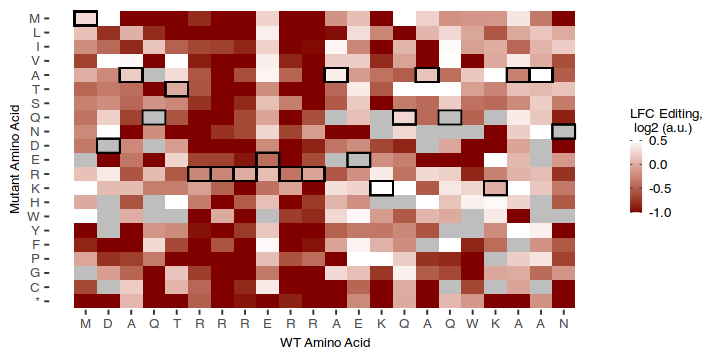

In [225]:
aa_reorder_list <- c("M", "L", "I", "V", "A", "T", "S", "Q", "N", "D", "E", "R", "K", "H", "W", "Y", "F", "P", "G", "C", "*")

calc_fraction_bootstrap <- function(data, indices) {
  d <- data[indices,]
  1-(sum(d$num_0_c)/sum(d$read_counts))
}
set.seed <- 1234

wt_aa_order<- target_data %>% select(codon_position,wt_aa) %>% distinct() %>% arrange(codon_position)
x_order<-wt_aa_order$wt_aa
x_breaks <- wt_aa_order$codon_position

wt_data <- target_data %>%
    mutate(is_wt= mut_aa==wt_aa)%>%
    filter(is_wt)%>%
    select(codon_position,mut_aa)%>%
    print()

lfc_data <- target_data  %>%
  group_by(codon_position,mut_aa,wt_aa)%>%
  filter(sum(read_counts)>10,n()>3)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  print()

wt_editing<-lfc_data%>%
    filter(wt_aa==mut_aa) %>% 
    pull(fraction_edited) %>%
    median()%>%
    print()

full_grid <- expand_grid(
  codon_position = unique(lfc_data$codon_position),
  mut_aa = aa_reorder_list 
)

lfc_normalized<-lfc_data %>%
    mutate(lfc=log2(fraction_edited)-log2(wt_editing))%>%
    right_join(full_grid, by = c("codon_position", "mut_aa"))

lfc_normalized%>%
    ggplot(aes(x=codon_position,y=mut_aa,fill=lfc))+
        geom_tile()+
        geom_tile(data = wt_data, 
            aes(x = codon_position, y = mut_aa), 
            color = "black", fill = NA, linewidth = 0.5) +  # draw red outline on wt aa
    #     scale_fill_gradient2(
    #         name = "LFC",
    #         low = "blue",       
    #         # mid = "white",      
    #         high = "red",
    #         oob = scales::squish,      
    #         limits = c(-1, 1),      
    #         guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"),
    #         na.value = "grey"
    # )+
        scale_fill_gradient(
            name="LFC Editing,\n log2 (a.u.)",
            low = "#800000", high = "#FFFFFF",
            oob = scales::squish,
            limits = c(-1, 0.5),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "grey")+
        scale_y_discrete(limits = rev(aa_reorder_list))+
        scale_x_continuous(breaks=x_breaks,labels=x_order)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            )+
        labs(x = "WT Amino Acid", y = "Mutant Amino Acid",
         )
ggsave("../figures/lfc_heatmap_filtered.pdf",height = 3,width = 4)


# A tibble: 22 × 3
   codon_position fraction_edited fraction_sd
            <dbl>           <dbl>       <dbl>
 1              9          0.229      0.0122 
 2              8          0.103      0.00400
 3              6          0.118      0.00648
 4             10          0.109      0.00576
 5             22          0.157      0.0168 
 6              1          0.180      0.0123 
 7             18          0.148      0.0107 
 8             14          0.159      0.0137 
 9             16          0.159      0.0109 
10              7          0.0975     0.00575
# … with 12 more rows


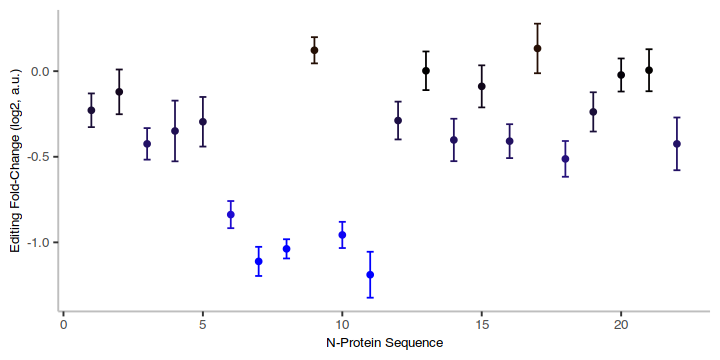

In [177]:
options(repr.plot.width = 6, repr.plot.height = 3)

wt_aa_order<- target_data %>% select(codon_position,wt_aa) %>% distinct() %>% arrange(codon_position) %>% pull(wt_aa)

calc_fraction_bootstrap <- function(data, indices) {
  d <- data[indices,]
  1-(sum(d$num_0_c)/sum(d$read_counts))
}
set.seed <- 1234

lfc_by_position <- target_data  %>%
  filter(wt_aa!=mut_aa) %>%
  group_by(codon_position)%>%
  filter(sum(read_counts)>10,n()>3)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  print()

lfc_normalized_by_position<-lfc_by_position %>%
    mutate(lfc=log2(fraction_edited)-log2(wt_editing),
    lfc_sd = fraction_sd / (fraction_edited * log(2)))

wt_aa_order=c("")

lfc_normalized_by_position %>%
  ggplot(aes(x = codon_position, y = lfc,color=lfc)) +  
  geom_point() +
  geom_errorbar(aes(ymin = (lfc - lfc_sd), ymax = (lfc + lfc_sd)), width = 0.25) +
  scale_color_gradient2(
    name = "LFC",
    low = "blue",       
    mid = "black",      
    high = "red",
    oob = scales::squish,      
    limits = c(-1, 1),      
    guide = FALSE,
    na.value = "grey"
    )+
  # scale_y_continuous(limits = c(0, 33)) +
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "N-Protein Sequence", y = "Editing Fold-Change (log2, a.u.)")



In [178]:
lfc_normalized %>%
filter(wt_aa!=mut_aa)%>%
group_by(codon_position)%>%
summarize(mean_lfc=mean(lfc))%>%
filter(codon_position>1)%>%
write_csv("../tables/dms_data.csv")

In [145]:
lfc_data %>% arrange(lfc) %>% filter(codon_position==2) %>% print(n=16)

# A tibble: 16 × 5
   codon_position mut_aa fraction_edited fraction_sd     lfc
            <dbl> <chr>            <dbl>       <dbl>   <dbl>
 1              2 F              0.00594     0.00159 -5.01  
 2              2 *              0.0894      0.0360  -1.10  
 3              2 E              0.111       0.0600  -0.792 
 4              2 L              0.116       0.0481  -0.722 
 5              2 P              0.125       0.0492  -0.623 
 6              2 I              0.149       0.0470  -0.361 
 7              2 T              0.163       0.0723  -0.235 
 8              2 A              0.166       0.0388  -0.207 
 9              2 S              0.175       0.0484  -0.136 
10              2 G              0.202       0.0924   0.0761
11              2 K              0.213       0.0791   0.152 
12              2 Q              0.252       0.0891   0.392 
13              2 R              0.269       0.0454   0.489 
14              2 M              0.288       0.0769   0.588 
15   

### Other Plots

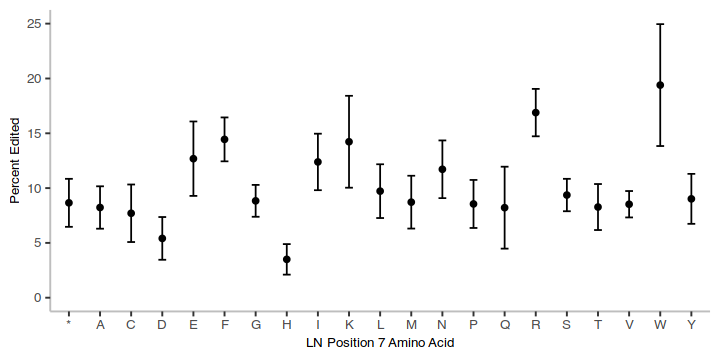

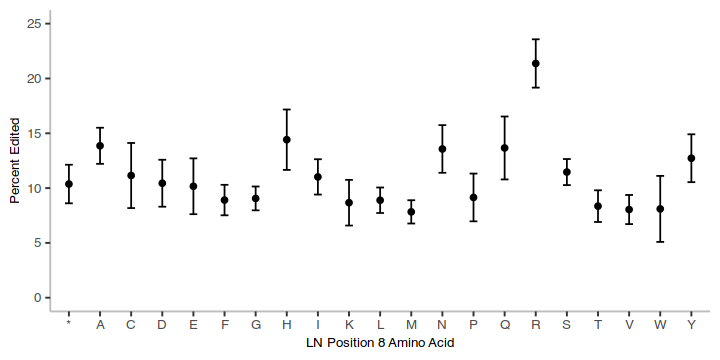

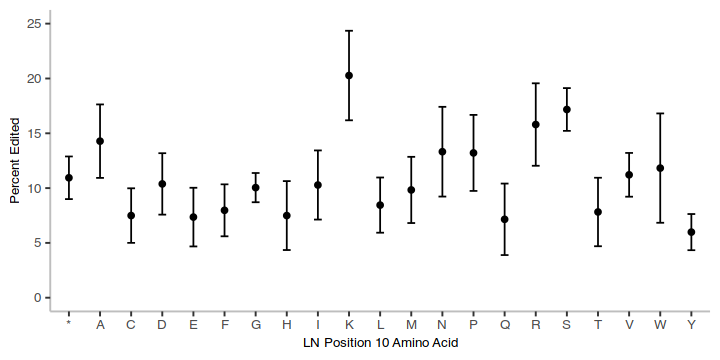

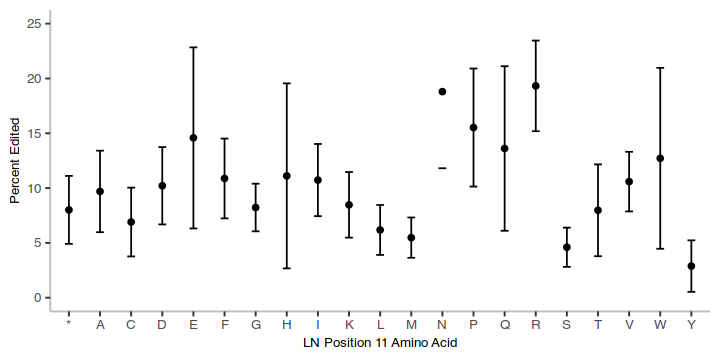

In [132]:

lfc_data  %>%
  filter(codon_position==7)%>%
  ggplot(aes(x = mut_aa, y = fraction_edited*100)) +  
  geom_point() +
  geom_errorbar(aes(ymin = (fraction_edited - fraction_sd)*100, ymax = (fraction_edited + fraction_sd)*100), width = 0.25) +
  scale_y_continuous(limits = c(0, 25)) +
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "LN Position 7 Amino Acid", y = "Percent Edited")

lfc_data  %>%
  filter(codon_position==8)%>%
  ggplot(aes(x = mut_aa, y = fraction_edited*100)) +  
  geom_point() +
  geom_errorbar(aes(ymin = (fraction_edited - fraction_sd)*100, ymax = (fraction_edited + fraction_sd)*100), width = 0.25) +
  scale_y_continuous(limits = c(0, 25)) +
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "LN Position 8 Amino Acid", y = "Percent Edited")

lfc_data  %>%
  filter(codon_position==10)%>%
  ggplot(aes(x = mut_aa, y = fraction_edited*100)) +  
  geom_point() +
  geom_errorbar(aes(ymin = (fraction_edited - fraction_sd)*100, ymax = (fraction_edited + fraction_sd)*100), width = 0.25) +
  scale_y_continuous(limits = c(0, 25)) +
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "LN Position 10 Amino Acid", y = "Percent Edited")

lfc_data  %>%
  filter(codon_position==11)%>%
  ggplot(aes(x = mut_aa, y = fraction_edited*100)) +  
  geom_point() +
  geom_errorbar(aes(ymin = (fraction_edited - fraction_sd)*100, ymax = (fraction_edited + fraction_sd)*100), width = 0.25) +
  scale_y_continuous(limits = c(0, 25)) +
  guides(color="none")+
    theme(
      plot.title = element_text(size = 18, face = "bold"),
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      axis.line = element_line(color = "grey"),
    )+
    labs(x = "LN Position 11 Amino Acid", y = "Percent Edited")

### Logo Plot for Residues 3 through 15

In [269]:
calc_fraction_bootstrap <- function(data, indices) {
  d <- data[indices,]
  1-(sum(d$num_0_c)/sum(d$read_counts))
}
set.seed <- 1234

editing_data <- target_data  %>%
  group_by(codon_position,mut_aa,wt_aa)%>%
  filter(sum(read_counts)>10,n()>3)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  print()

wt_editing<-editing_data%>%
    filter(wt_aa==mut_aa) %>% 
    pull(fraction_edited) %>%
    median()%>%
    print()

lfc_data<-editing_data %>%
    mutate(lfc=log2(fraction_edited)-log2(wt_editing))%>%
    select(codon_position,mut_aa,lfc)%>%
    print()

# pwm<-plot_data %>%
#     group_by(base,position)%>%
#     summarize(weight=sum(affinity_score),.groups="drop")%>%
#     group_by(position)%>%
#     mutate(probability = weight / sum(weight)) %>%
#     ungroup()%>%
#     mutate(base_rc=case_when(
#         base=="A" ~ "U",
#         base=="T" ~ "A",
#         base=="C" ~ "G",
#         base=="G" ~ "C"
#     ),
#     position=as.numeric(position))%>%
#     select(-base,-weight)%>%
#     arrange(position,base_rc)%>%
#     pivot_wider(names_from = position, values_from = probability, values_fill = 0) %>%
#     print()

# pwm_matrix <- pwm %>%
#   select(-base_rc) %>%
#   as.matrix() %>%
#   `rownames<-`(c("A","C","G","U"))

# # # Calculate information content for each position
# # # H = -sum(p * log2(p)), R = 2 - H
# # info_content <- apply(pwm_matrix, 2, function(column) {
# #     probs <- column[column > 0]  # Exclude zero probabilities
# #     H <- -sum(probs * log2(probs))  # Shannon entropy
# #     R <- 2 - H  # Max entropy for 4 bases is 2 bits
# #     return(R)
# # })

# # # Rescale probabilities by information content
# # pwm_bits <- sweep(pwm_matrix, 2, info_content, FUN = "*")

# ggseqlogo(pwm_matrix, method = "custom") +
#     theme_classic()+
#     theme(
#         axis.title = element_text(size = 8),
#         axis.text = element_text(size = 8),
#         legend.title = element_text(size = 8),
#         legend.text = element_text(size = 8),
#         axis.line = element_line(color = "grey")
#         )+
#     # scale_x_continuous(labels=c("8","9","10","11","12"))+
#     labs(x = "boxB Loop Position", y="Probability")
    
# ggsave("../figures/in_vivo_probabiliy_plot_ln_tada.pdf",height = 1.5,width = 2.0)

# A tibble: 420 × 5
   codon_position wt_aa mut_aa fraction_edited fraction_sd
            <dbl> <chr> <chr>            <dbl>       <dbl>
 1              9 E     R               0.226       0.0288
 2              8 R     A               0.140       0.0222
 3              6 R     S               0.121       0.0204
 4              6 R     W               0.0848      0.0228
 5             10 R     K               0.193       0.0452
 6             22 N     K               0.147       0.125 
 7              1 M     T               0.152       0.0430
 8             18 W     *               0.184       0.0731
 9             14 K     F               0.222       0.0513
10              1 M     R               0.227       0.0296
# … with 410 more rows
[1] 0.2109254
# A tibble: 420 × 3
   codon_position mut_aa     lfc
            <dbl> <chr>    <dbl>
 1              9 R       0.0980
 2              8 A      -0.593 
 3              6 S      -0.807 
 4              6 W      -1.31  
 5             10

# A tibble: 21 × 13
   mut_aa     `4`      `5`    `6`    `7`    `8`    `9`   `10`   `11`   `12`
   <chr>    <dbl>    <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
 1 *      0.0560  0.0244   0.0536 0.0398 0.0468 0.0133 0.0483 0.0368 0.0211
 2 C      0.0375  0.0665   0.0589 0.0368 0.0500 0.0669 0.0335 0.0315 0.0245
 3 E      0.00258 0.0731   0.0524 0.0560 0.0437 0.0368 0.0331 0.0698 0     
 4 F      0.115   0.0432   0.0331 0.0639 0.0378 0.0597 0.0365 0.0479 0.0631
 5 G      0.0295  0.0686   0.0474 0.0403 0.0402 0.0369 0.0440 0.0386 0.0748
 6 I      0.0987  0.0453   0.0497 0.0586 0.0476 0.0577 0.0444 0.0495 0.0855
 7 K      0.0757  0.0469   0.0776 0.0662 0.0378 0.0373 0.0843 0.0390 0.0769
 8 L      0.0558  0.0226   0.0379 0.0435 0.0385 0.0621 0.0376 0.0276 0.0308
 9 M      0.0452  0.000756 0.0477 0.0422 0.0350 0.0575 0.0437 0.0275 0.0501
10 N      0.0768  0.0243   0.0328 0.0530 0.0594 0.0580 0.0574 0.0938 0.0174
# … with 11 more rows, and 3 more variables: `13` <dbl>, `14` <dbl>,

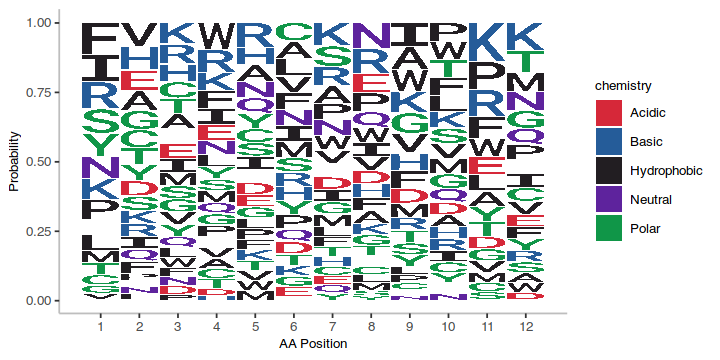

In [ ]:
plot_data <- target_data  %>%
  mutate(across(matches("num_._c"), ~ round(.x / read_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_c) %>%


pwm<-plot_data %>%
    group_by(mut_aa,codon_position)%>%
    filter(codon_position>3,codon_position<16)%>%
    summarize(weight=sum(fraction_edited),.groups="drop")%>%
    group_by(codon_position)%>%
    mutate(probability = weight / sum(weight)) %>%
    ungroup()%>%
    select(-weight)%>%
    mutate(codon_position=as.numeric(codon_position))%>%
    arrange(codon_position,mut_aa)%>%
    pivot_wider(names_from = codon_position, values_from = probability, values_fill = 0) %>%
    print()

row_names<-pwm$mut_aa

pwm_matrix <- pwm %>%
  select(-mut_aa) %>%
  as.matrix() %>%
  `rownames<-`(row_names)

# Set max entropy for 21 symbols (20 AAs + stop codon)
max_entropy <- log2(21)

# Calculate information content per column (position)
info_content <- apply(pwm_matrix, 2, function(column) {
    probs <- column[column > 0]  # Exclude zero probabilities
    H <- -sum(probs * log2(probs))  # Shannon entropy
    R <- max_entropy - H  # Information content
    return(R)
})
# Rescale probabilities by information content
pwm_bits <- sweep(pwm_matrix, 2, info_content, FUN = "*")

ggseqlogo(pwm_matrix, method = "custom") +
    theme_classic()+
    theme(
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        axis.line = element_line(color = "grey")
        )+
    # scale_x_continuous(labels=c("4","5","6","7","8","9","10","11","12","13","14","15"))+
    labs(x = "AA Position", y="Probability")


### Different Logo Plot

- i'm going to try it a different way: using the average editing frequency at that position as the "background" such that amino acids further from the average are flagged at having information content.

In [237]:
background_aa<-target_data %>% 
  group_by(codon_position)%>%
  summarize(background_edits=1-(sum(num_0_c)/sum(read_counts))) %>%
  pivot_wider(names_from=codon_position,values_from=background_edits)%>%
  print()

edited_reads <- target_data %>%
  group_by(codon_position,mut_aa)%>%
  summarize(frequency=sum(num_0_c)/sum(read_counts),.groups="drop")%>%
  print()

pwm<-edited_reads %>%
    group_by(codon_position)%>%
    mutate(probability = frequency / sum(frequency)) %>%
    ungroup()%>%
    select(-frequency)%>%
    mutate(codon_position=as.numeric(codon_position))%>%
    arrange(codon_position,mut_aa)%>%
    pivot_wider(names_from = codon_position, values_from = probability, values_fill = 0) %>%
    print()
    
# row_names<-pwm$mut_aa

# pwm_matrix <- pwm %>%
#   select(-mut_aa) %>%
#   as.matrix() %>%
#   `rownames<-`(row_names)

# # Set max entropy for 21 symbols (20 AAs + stop codon)
# max_entropy <- log2(21)

# # Calculate information content per column (position)
# info_content <- apply(pwm_matrix, 2, function(column) {
#     probs <- column[column > 0]  # Exclude zero probabilities
#     H <- -sum(probs * log2(probs))  # Shannon entropy
#     R <- max_entropy - H  # Information content
#     return(R)
# })
# # Rescale probabilities by information content
# pwm_bits <- sweep(pwm_matrix, 2, info_content, FUN = "*")

# ggseqlogo(pwm_bits, method = "custom") +
#     theme_classic()+
#     theme(
#         axis.title = element_text(size = 8),
#         axis.text = element_text(size = 8),
#         legend.title = element_text(size = 8),
#         legend.text = element_text(size = 8),
#         axis.line = element_line(color = "grey")
#         )+
#     # scale_x_continuous(labels=c("4","5","6","7","8","9","10","11","12","13","14","15"))+
#     labs(x = "AA Position", y="Probability")


# A tibble: 1 × 22
    `1`   `2`   `3`   `4`   `5`   `6`   `7`   `8`   `9`  `10`   `11`  `12`  `13`
  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>  <dbl> <dbl> <dbl>
1 0.201 0.190 0.161 0.166 0.172 0.122 0.103 0.108 0.226 0.112 0.0968 0.183 0.211
# … with 9 more variables: `14` <dbl>, `15` <dbl>, `16` <dbl>, `17` <dbl>,
#   `18` <dbl>, `19` <dbl>, `20` <dbl>, `21` <dbl>, `22` <dbl>
# A tibble: 460 × 3
   codon_position mut_aa frequency
            <dbl> <chr>      <dbl>
 1              1 *          0.955
 2              1 A          0.798
 3              1 C          0.871
 4              1 D          0.792
 5              1 E          0.865
 6              1 F          0.885
 7              1 G          0.863
 8              1 H          0.774
 9              1 I          0.815
10              1 K          0.715
# … with 450 more rows
# A tibble: 21 × 23
   mut_aa    `1`    `2`    `3`    `4`    `5`    `6`    `7`    `8`    `9`   `10`
   <chr>   <dbl>  <dbl>  <dbl>  <dbl>

### Logo Plots Suck in this Context

- I think that this data structure is not suited to logo plots- which are more suited to datasets in which there are varying sequence preferences (ie the data is a collection of sequences). It seemed at first that I could just convert editing frequency to sequence frequency 
- Weight value is then "of all edited reads, how many of them occur with this character in this place" which then weights residues that don't actually matter as having more "information content".  But the reverse "of all non-edited reads, how many of them occur with this character in this place" doesn't seem to give good info content either- missing or insufficient data combinations become excessively important.
- It just isn't good because I don't really care about the distribution of the total edits across the sequence space- I care about deviations from the average, ideally within each position.
- The question is actually: which sequence/aa combinations deviate most strongly from the average or expected value (ie, wildtype editing value)

In [239]:
calc_fraction_bootstrap <- function(data, indices) {
  d <- data[indices,]
  1-(sum(d$num_0_c)/sum(d$read_counts))
}
set.seed <- 1234

mean_by_position <- target_data  %>%
  group_by(codon_position)%>%
  filter(sum(read_counts)>10,n()>3)%>% 
  # i don't trust things with less barcodes
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(mean_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(mean_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  print()


# A tibble: 22 × 3
   codon_position mean_edited mean_sd
            <dbl>       <dbl>   <dbl>
 1              9       0.226 0.0119 
 2              8       0.108 0.00406
 3              6       0.122 0.00571
 4             10       0.113 0.00648
 5             22       0.156 0.0163 
 6              1       0.200 0.0132 
 7             18       0.147 0.0115 
 8             14       0.165 0.0144 
 9             16       0.164 0.0127 
10              7       0.102 0.00573
# … with 12 more rows


In [240]:
calc_fraction_bootstrap <- function(data, indices) {
  d <- data[indices,]
  1-(sum(d$num_0_c)/sum(d$read_counts))
}
set.seed <- 1234

editing_data <- target_data  %>%
  group_by(codon_position,mut_aa,wt_aa)%>%
  filter(sum(read_counts)>10,n()>3)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  left_join(mean_by_position,by="codon_position")%>%
  mutate(z_score=(fraction_edited-mean_edited)/fraction_sd)%>%
  print()

# A tibble: 420 × 8
   codon_position wt_aa mut_aa fraction_edited fractio…¹ mean_…² mean_sd z_score
            <dbl> <chr> <chr>            <dbl>     <dbl>   <dbl>   <dbl>   <dbl>
 1              9 E     R               0.222     0.0325   0.226 0.0119  -0.0984
 2              8 R     A               0.140     0.0203   0.108 0.00406  1.55  
 3              6 R     S               0.114     0.0187   0.122 0.00571 -0.423 
 4              6 R     W               0.0895    0.0248   0.122 0.00571 -1.32  
 5             10 R     K               0.189     0.0414   0.113 0.00648  1.84  
 6             22 N     K               0.150     0.120    0.156 0.0163  -0.0466
 7              1 M     T               0.153     0.0391   0.200 0.0132  -1.19  
 8             18 W     *               0.187     0.0676   0.147 0.0115   0.591 
 9             14 K     F               0.213     0.0482   0.165 0.0144   0.990 
10              1 M     R               0.224     0.0270   0.200 0.0132   0.905 
# … with

# A tibble: 63 × 8
   codon_position wt_aa mut_aa fraction_edited fractio…¹ mean_…² mean_sd z_score
            <dbl> <chr> <chr>            <dbl>     <dbl>   <dbl>   <dbl>   <dbl>
 1              1 M     M              0.254     0.0249    0.200 0.0132     2.17
 2              1 M     W              0.495     0.133     0.200 0.0132     2.22
 3              1 M     Y              0.0573    0.0308    0.200 0.0132    -4.62
 4              1 M     *              0.0464    0.0260    0.200 0.0132    -5.89
 5              2 D     *              0.0869    0.0336    0.192 0.0197    -3.14
 6              2 D     F              0.00588   0.00176   0.192 0.0197  -106.  
 7              3 A     F              0.0758    0.0374    0.163 0.00855   -2.33
 8              3 A     M              0.0602    0.0235    0.163 0.00855   -4.38
 9              3 A     V              0.285     0.0368    0.163 0.00855    3.31
10              3 A     N              0.0178    0.0154    0.163 0.00855   -9.44
# … with 

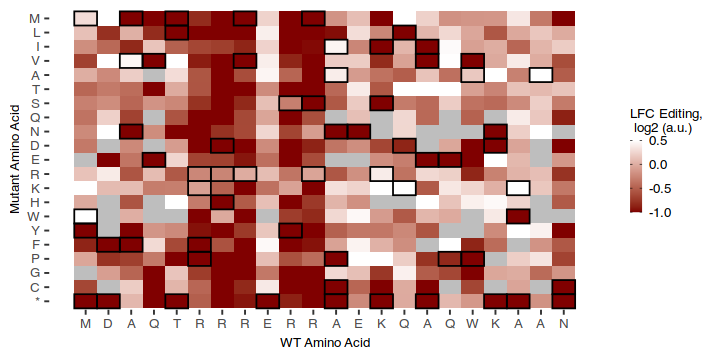

In [246]:
outliers<-editing_data %>%
    filter(z_score > 2 |z_score< -2) %>%
    arrange(codon_position)%>%
    print()

lfc_normalized%>%
    ggplot(aes(x=codon_position,y=mut_aa,fill=lfc))+
        geom_tile()+
        geom_tile(data = outliers, 
            aes(x = codon_position, y = mut_aa), 
            color = "black", fill = NA, linewidth = 0.5) +  # draw red outline on significant values
    #     scale_fill_gradient2(
    #         name = "LFC",
    #         low = "blue",       
    #         # mid = "white",      
    #         high = "red",
    #         oob = scales::squish,      
    #         limits = c(-1, 1),      
    #         guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"),
    #         na.value = "grey"
    # )+
        scale_fill_gradient(
            name="LFC Editing,\n log2 (a.u.)",
            low = "#800000", high = "#FFFFFF",
            oob = scales::squish,
            limits = c(-1, 0.5),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "grey")+
        scale_y_discrete(limits = rev(aa_reorder_list))+
        scale_x_continuous(breaks=x_breaks,labels=x_order)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.text = element_text(size = 8),
            )+
        labs(x = "WT Amino Acid", y = "Mutant Amino Acid",
         )

In [264]:
mean_by_position <- target_data  %>%
  mutate(across(matches("num_._c"), ~ round(.x / read_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_c)%>%
  group_by(codon_position)%>%
  filter(sum(read_counts)>10,n()>3)%>% 
  # i don't trust things with less barcodes
  summarize(mean_edited=mean(fraction_edited),mean_sd=sd(fraction_edited))%>%
  ungroup() %>%
  print()

outlier_data <- target_data  %>%
  filter(read_counts>20) %>%
  mutate(across(matches("num_._c"), ~ round(.x / read_counts, 5), .names = "fraction_{col}")) %>%
  mutate(fraction_edited=1-fraction_num_0_c)%>%
  select(codon_position,mut_aa,fraction_edited)%>%
    left_join(mean_by_position,by="codon_position")%>%
    mutate(z_score=(fraction_edited-mean_edited)/mean_sd,outlier= z_score>2|z_score< -2)%>%
    # # how does this data point compare to the average at that position?
  group_by(codon_position,mut_aa)%>%
  summarize(fraction_outlier=sum(outlier)/n(),n=n())%>%
  filter(n>3)%>%
  arrange(-fraction_outlier)%>%
  print()

# A tibble: 22 × 3
   codon_position mean_edited mean_sd
            <dbl>       <dbl>   <dbl>
 1              1       0.220   0.302
 2              2       0.215   0.278
 3              3       0.155   0.243
 4              4       0.139   0.228
 5              5       0.172   0.240
 6              6       0.127   0.221
 7              7       0.106   0.205
 8              8       0.116   0.214
 9              9       0.234   0.288
10             10       0.110   0.210
# … with 12 more rows


`summarise()` has grouped output by 'codon_position'. You can override using
the `.groups` argument.


# A tibble: 418 × 4
# Groups:   codon_position [22]
   codon_position mut_aa fraction_outlier     n
            <dbl> <chr>             <dbl> <int>
 1             14 K                 0.429     7
 2             16 H                 0.375     8
 3              1 S                 0.333    15
 4             12 W                 0.333     6
 5              3 C                 0.3      10
 6              5 C                 0.286     7
 7             17 V                 0.286    14
 8              1 W                 0.25      4
 9              2 N                 0.25      8
10              5 H                 0.25      4
# … with 408 more rows


# A tibble: 21 × 23
   mut_aa    `1`    `2`    `3`   `4`    `5`    `6`    `7`    `8`    `9`   `10`
   <chr>   <dbl>  <dbl>  <dbl> <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
 1 *      0      0.135  0      0     0      0.0212 0.0220 0.0328 0      0.0362
 2 A      0.109  0.0993 0.106  0     0.0615 0.0782 0      0.0765 0.0300 0.0840
 3 C      0.127  0      0.237  0.204 0.211  0.0537 0.105  0      0      0     
 4 D      0      0      0.0989 0     0      0.0326 0.0280 0.0298 0      0     
 5 F      0      0      0.0609 0.181 0      0.0405 0.0813 0.0147 0.165  0     
 6 H      0      0      0      0     0.184  0.101  0.0625 0.102  0      0     
 7 I      0      0      0.0465 0.163 0      0.0702 0.0542 0.0336 0.110  0.0339
 8 K      0.0953 0      0.0528 0     0.123  0.0570 0.0878 0.0427 0      0.175 
 9 L      0.0565 0      0.0416 0     0      0.0309 0.0166 0.0342 0.106  0.0438
10 M      0.0618 0      0      0     0      0.0811 0.0387 0.0288 0.0583 0.0875
# … with 11 more rows, and 12 mo

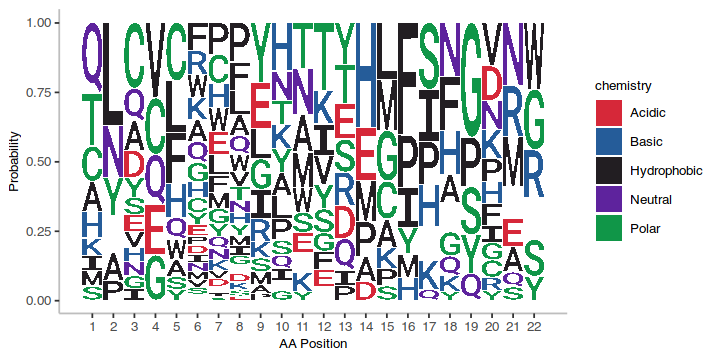

In [268]:
pwm<-outlier_data %>%
    group_by(codon_position)%>%
    mutate(probability = fraction_outlier / sum(fraction_outlier)) %>%
    ungroup()%>%
    select(-fraction_outlier,-n)%>%
    mutate(codon_position=as.numeric(codon_position))%>%
    arrange(codon_position,mut_aa)%>%
    pivot_wider(names_from = codon_position, values_from = probability, values_fill = 0) %>%
    print()

pwm_matrix <- pwm %>%
  select(-mut_aa) %>%
  as.matrix() %>%
  `rownames<-`(row_names)

# Set max entropy for 21 symbols (20 AAs + stop codon)
max_entropy <- log2(21)

# Calculate information content per column (position)
info_content <- apply(pwm_matrix, 2, function(column) {
    probs <- column[column > 0]  # Exclude zero probabilities
    H <- -sum(probs * log2(probs))  # Shannon entropy
    R <- max_entropy - H  # Information content
    return(R)
})
# Rescale probabilities by information content
pwm_bits <- sweep(pwm_matrix, 2, info_content, FUN = "*")

ggseqlogo(pwm_matrix, method = "custom") +
    theme_classic()+
    theme(
        axis.title = element_text(size = 8),
        axis.text = element_text(size = 8),
        legend.title = element_text(size = 8),
        legend.text = element_text(size = 8),
        axis.line = element_line(color = "grey")
        )+
    labs(x = "AA Position", y="Probability")